# Projection tutorial

### This tutorial shows how to project points and semantic segmentation on a image.
#### 1.Import required python modules and load sequence data.

In [2]:
import pandaset
import os

# load dataset
dataset = pandaset.DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq002 = dataset["002"]
seq002.load()

print("avaliable cameras: ", seq002.camera.keys())

avaliable cameras:  dict_keys(['left_camera', 'back_camera', 'right_camera', 'front_left_camera', 'front_camera', 'front_right_camera'])


In [3]:
seq002 = dataset['002']
seq002.load_lidar()

print("Available lidar frames:", len(seq002.lidar.data))
print("Indices:", list(range(len(seq002.lidar.data)))[:10])  # just first 10 indices


Available lidar frames: 80
Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [4]:
seq002 = dataset['002']
seq002.load_lidar().load_cuboids()
pc0 = seq002.lidar[0]
print(pc0.head())


                x           y         z     i             t  d
index                                                         
0      -75.131138  -79.331690  3.511804   7.0  1.557540e+09  0
1     -112.588306 -118.666002  1.423499  31.0  1.557540e+09  0
2      -42.085902  -44.384891  0.593491   7.0  1.557540e+09  0
3      -27.329435  -28.795053 -0.403781   0.0  1.557540e+09  0
4       -6.196208   -6.621082  1.130009   3.0  1.557540e+09  0


In [5]:
pc0 = seq002.lidar[0]
print(pc0)

                 x           y         z     i             t  d
index                                                          
0       -75.131138  -79.331690  3.511804   7.0  1.557540e+09  0
1      -112.588306 -118.666002  1.423499  31.0  1.557540e+09  0
2       -42.085902  -44.384891  0.593491   7.0  1.557540e+09  0
3       -27.329435  -28.795053 -0.403781   0.0  1.557540e+09  0
4        -6.196208   -6.621082  1.130009   3.0  1.557540e+09  0
...            ...         ...       ...   ...           ... ..
166763   27.670526   17.159726  3.778677  25.0  1.557540e+09  1
166764   27.703935   17.114063  3.780626  27.0  1.557540e+09  1
166765   27.560664   16.955518  3.767948  18.0  1.557540e+09  1
166766   27.384433   16.783824  3.752670  22.0  1.557540e+09  1
166767   27.228821   16.626038  3.739154  20.0  1.557540e+09  1

[166768 rows x 6 columns]


#### 2.Use projection function in pandaset.geometry to get projection 2d-points on image.
- ***geometry.projection***
    - input
        - ***lidar_points***(np.array(\[N, 3\])): lidar points in the world coordinates.
        - ***camera_data***(PIL.Image): image for one camera in one frame.
        - ***camera_pose***: pose in the world coordinates for one camera in one frame.
        - ***camera_intrinsics***: intrinsics for one camera in one frame.
        - ***filter_outliers***(bool): filtering projected 2d-points out of image.
    - output
        - ***projection_points2d***(np.array(\[K, 2\])): projected 2d-points in pixels.
        - ***camera_points_3d***(np.array(\[K, 3\])): 3d-points in pixels in the camera frame.
        - ***inliner_idx***(np.array(\[K, 2\])): the indices for *lidar_points* whose projected 2d-points are inside image.

In [6]:
from pandaset import geometry

# generate projected points
seq_idx = 1
camera_name = "front_camera"
lidar = seq002.lidar
points3d_lidar_xyz = lidar.data[seq_idx].to_numpy()[:, :3]
choosen_camera = seq002.camera[camera_name]
projected_points2d, camera_points_3d, inner_indices = geometry.projection(lidar_points=points3d_lidar_xyz, 
                                                                          camera_data=choosen_camera[seq_idx],
                                                                          camera_pose=choosen_camera.poses[seq_idx],
                                                                          camera_intrinsics=choosen_camera.intrinsics,
                                                                          filter_outliers=True)
print("projection 2d-points inside image count:", projected_points2d.shape)

projection 2d-points inside image count: (68659, 2)


#### 3.Show original image.

Populating the interactive namespace from numpy and matplotlib


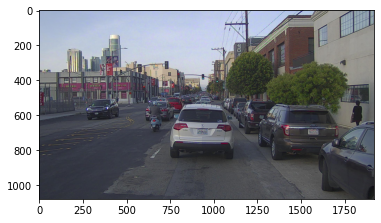

In [7]:
from matplotlib import pyplot as plt
%pylab inline

# image before projection
ori_image = seq002.camera[camera_name][seq_idx]
plt.imshow(ori_image)

#### 4.Show projected points on image colorized by distances.

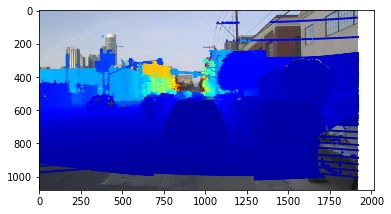

In [8]:
import matplotlib.cm as cm
import numpy as np

# image after projection
plt.imshow(ori_image)
distances = np.sqrt(np.sum(np.square(camera_points_3d), axis=-1))
colors = cm.jet(distances / np.max(distances))
plt.gca().scatter(projected_points2d[:, 0], projected_points2d[:, 1], color=colors, s=1)

#### 5.Show projected points on image colorized by semantic segmentation.

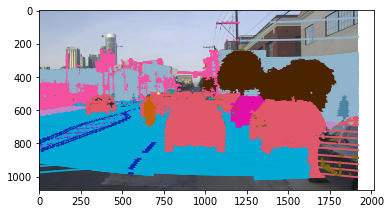

In [9]:
import matplotlib.cm as cm
import numpy as np
import random

# image after projection
plt.imshow(ori_image)

# load semseg
semseg = seq002.semseg[seq_idx].to_numpy()

# get semseg on image by filting outside points
semseg_on_image = semseg[inner_indices].flatten()

# random gnerate colors for semseg
max_seg_id = np.max(semseg_on_image)
color_maps = [(random.random(), random.random(), random.random()) for _ in range(max_seg_id + 1)]
colors = np.array([color_maps[seg_id] for seg_id in semseg_on_image])

plt.gca().scatter(projected_points2d[:, 0], projected_points2d[:, 1], color=colors, s=1)

In [10]:
seq002.load_lidar().load_cuboids()


In [11]:
seq002.load_lidar().load_cuboids()

In [12]:
# Access cuboids from a specific frame index
cuboids_frame0 = seq002.cuboids[0]
print(type(cuboids_frame0))
print(cuboids_frame0.keys())   # usually contains: 'uuid', 'position', 'dimension', 'yaw', 'label'


<class 'pandas.core.frame.DataFrame'>
Index(['uuid', 'label', 'yaw', 'stationary', 'camera_used', 'position.x',
       'position.y', 'position.z', 'dimensions.x', 'dimensions.y',
       'dimensions.z', 'attributes.object_motion', 'cuboids.sibling_id',
       'cuboids.sensor_id', 'attributes.rider_status',
       'attributes.pedestrian_behavior', 'attributes.pedestrian_age'],
      dtype='object')


                                   uuid label       yaw  stationary  \
0  e83d78e4-5b11-4ad5-ac71-917b5cd19c94   Car -0.840044        True   
1  b113987c-bde4-43b3-b7f2-8a9a80318ae2   Car  2.352911        True   
2  47a397d6-9f2f-4e3b-9316-00ad60320f6d   Car  2.387817        True   
3  92b61b3d-8f2f-4205-921b-fdc047ab86e2   Car -0.787685        True   
4  895e6a77-1506-4f55-a977-baf5f86840e1   Car  2.405271        True   

   camera_used  position.x  position.y  position.z  dimensions.x  \
0            2       7.361       2.630       0.487         1.888   
1            5     -12.659       6.353       0.361         1.837   
2            4     -41.504     -22.578       0.393         1.930   
3            1      11.697       7.260       0.548         2.099   
4            4     -51.568     -32.920       0.486         1.967   

   dimensions.y  dimensions.z attributes.object_motion cuboids.sibling_id  \
0         4.747         1.761                   Parked                  -   
1         

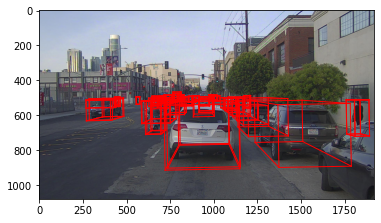

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from pandaset import geometry

# Choose a frame and camera
seq_idx = 0
camera_name = "front_camera"
camera = seq002.camera[camera_name]
camera.load()

# Load cuboids for this sequence
cuboids = seq002.cuboids

# Load the image for this frame
img = np.array(camera[seq_idx])   # convert PIL image to numpy
plt.imshow(img)

# Get cuboids for this frame (returns a pandas DataFrame)
frame_cuboids = cuboids[seq_idx]
print(frame_cuboids.head())

# Function: compute 8 corners of cuboid in LiDAR coordinates
def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # corner offsets before rotation
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # rotation around z-axis (yaw)
    rot = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ rot.T
    corners += np.array([x, y, z])
    return corners

# Project cuboid corners to 2D image space
def project_points(points3d, frame_idx):
    projected, _, inside = geometry.projection(
        lidar_points=points3d,
        camera_data=camera[frame_idx],
        camera_pose=camera.poses[frame_idx],
        camera_intrinsics=camera.intrinsics,
        filter_outliers=True
    )
    return projected, inside

# Draw cuboids on image
for _, cuboid in frame_cuboids.iterrows():
    corners = get_cuboid_corners(cuboid)
    proj, inside = project_points(corners, seq_idx)

    if proj.shape[0] != 8:  # skip if projection failed
        continue

    # draw cuboid edges
    edges = [
        (0,1), (1,2), (2,3), (3,0),  # bottom
        (4,5), (5,6), (6,7), (7,4),  # top
        (0,4), (1,5), (2,6), (3,7)   # verticals
    ]
    for i,j in edges:
        plt.plot([proj[i,0], proj[j,0]], [proj[i,1], proj[j,1]], 'r', linewidth=1)

plt.show()


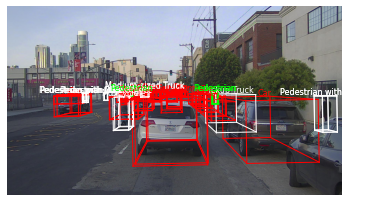

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from pandaset import geometry

# -----------------------------
# Choose sequence and camera
# -----------------------------
seq_idx = 0
camera_name = "front_camera"
camera = seq002.camera[camera_name]
camera.load()

# Load cuboids for this sequence
cuboids = seq002.cuboids

# Load image for the chosen frame
img = np.array(camera[seq_idx])   # convert PIL image to numpy
plt.imshow(img)

# -----------------------------
# Function: compute cuboid corners in LiDAR coordinates
# -----------------------------
def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # 8 corners relative to center
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # Rotation matrix (yaw around z-axis)
    rot = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ rot.T
    corners += np.array([x, y, z])
    return corners

# -----------------------------
# Function: project 3D points into 2D image
# -----------------------------
def project_points(points3d, frame_idx):
    projected, _, inside = geometry.projection(
        lidar_points=points3d,
        camera_data=camera[frame_idx],
        camera_pose=camera.poses[frame_idx],
        camera_intrinsics=camera.intrinsics,
        filter_outliers=True
    )
    return projected, inside

# -----------------------------
# Define colors by object class
# -----------------------------
label_colors = {
    "Car": "red",
    "Truck": "orange",
    "Bus": "purple",
    "Pedestrian": "lime",
    "Cyclist": "cyan",
    "Motorcyclist": "blue"
}

# -----------------------------
# Draw cuboids on image
# -----------------------------
frame_cuboids = cuboids[seq_idx]

for _, cuboid in frame_cuboids.iterrows():
    corners = get_cuboid_corners(cuboid)
    proj, inside = project_points(corners, seq_idx)

    if proj.shape[0] != 8:  # skip if projection failed
        continue

    # Select color by label
    color = label_colors.get(cuboid["label"], "white")

    # Draw cuboid edges
    edges = [
        (0,1), (1,2), (2,3), (3,0),  # bottom
        (4,5), (5,6), (6,7), (7,4),  # top
        (0,4), (1,5), (2,6), (3,7)   # verticals
    ]
    for i, j in edges:
        plt.plot([proj[i,0], proj[j,0]], [proj[i,1], proj[j,1]], color=color, linewidth=1)

    # Add label text above cuboid
    cx, cy = proj[:,0].mean(), proj[:,1].min() - 5
    plt.text(cx, cy, cuboid["label"], color=color, fontsize=8, ha="center")

plt.axis("off")
plt.show()


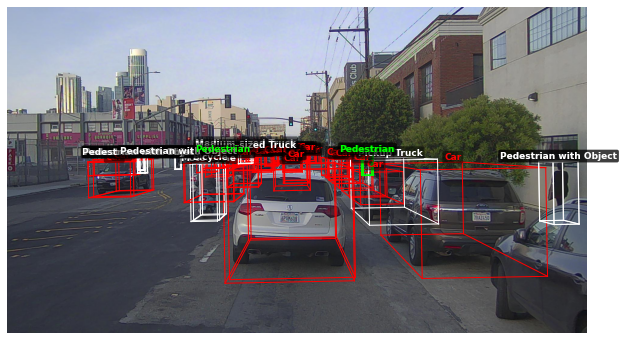

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from pandaset import geometry

# -----------------------------
# Choose sequence and camera
# -----------------------------
seq_idx = 0
camera_name = "front_camera"
camera = seq002.camera[camera_name]
camera.load()

# Load cuboids for this sequence
cuboids = seq002.cuboids

# Load image for the chosen frame
img = np.array(camera[seq_idx])   # convert PIL image to numpy
plt.figure(figsize=(12, 6))
plt.imshow(img)

# -----------------------------
# Function: compute cuboid corners in LiDAR coordinates
# -----------------------------
def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # 8 corners relative to center
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # Rotation matrix (yaw around z-axis)
    rot = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ rot.T
    corners += np.array([x, y, z])
    return corners

# -----------------------------
# Function: project 3D points into 2D image
# -----------------------------
def project_points(points3d, frame_idx):
    projected, _, inside = geometry.projection(
        lidar_points=points3d,
        camera_data=camera[frame_idx],
        camera_pose=camera.poses[frame_idx],
        camera_intrinsics=camera.intrinsics,
        filter_outliers=True
    )
    return projected, inside

# -----------------------------
# Define colors by object class
# -----------------------------
label_colors = {
    "Car": "red",
    "Truck": "orange",
    "Bus": "purple",
    "Pedestrian": "lime",
    "Cyclist": "cyan",
    "Motorcyclist": "blue",
    "Other": "white"
}

# -----------------------------
# Draw cuboids on image
# -----------------------------
frame_cuboids = cuboids[seq_idx]

for _, cuboid in frame_cuboids.iterrows():
    corners = get_cuboid_corners(cuboid)
    proj, inside = project_points(corners, seq_idx)

    if proj.shape[0] != 8:  # skip if projection failed
        continue

    # Select color by label
    color = label_colors.get(cuboid["label"], "white")

    # Draw cuboid edges
    edges = [
        (0,1), (1,2), (2,3), (3,0),  # bottom
        (4,5), (5,6), (6,7), (7,4),  # top
        (0,4), (1,5), (2,6), (3,7)   # verticals
    ]
    for i, j in edges:
        plt.plot([proj[i,0], proj[j,0]], [proj[i,1], proj[j,1]], color=color, linewidth=1)

    # Add label text slightly above cuboid
    cx, cy = proj[:,0].mean(), proj[:,1].min() - 8
    plt.text(
        cx, cy, cuboid["label"], 
        color=color, fontsize=9, ha="center", weight="bold",
        bbox=dict(facecolor="black", alpha=0.5, edgecolor="none", boxstyle="round,pad=0.2")
    )

plt.axis("off")
plt.show()


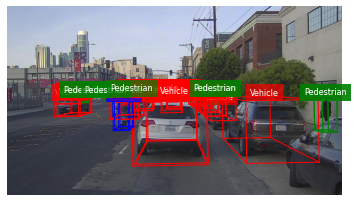

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pandaset import geometry

# Choose a frame and camera
seq_idx = 0
camera_name = "front_camera"
camera = seq002.camera[camera_name]
camera.load()

# Load cuboids (DataFrame per frame)
cuboids = seq002.cuboids
frame_cuboids = cuboids[seq_idx]

# Load the image
img = np.array(camera[seq_idx])   # PIL → numpy
plt.imshow(img)

# Mapping to KITTI-style classes
def map_to_kitti(label):
    vehicles = ["Car", "Vehicle", "Bus", "Truck", "Trailer", "Van"]
    pedestrians = ["Pedestrian", "Pedestrian with Object"]
    cyclists = ["Cyclist", "Motorcyclist", "Bicycle", "Motorcycle"]

    if label in vehicles:
        return "Vehicle"
    elif label in pedestrians:
        return "Pedestrian"
    elif label in cyclists:
        return "Cyclist"
    else:
        return None   # Ignore everything else

# Function: compute 3D cuboid corners in lidar coords
def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # Define corners
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # Rotate around z-axis
    rot = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ rot.T
    corners += np.array([x, y, z])
    return corners

# Projection function
def project_points(points3d, frame_idx):
    projected, _, inside = geometry.projection(
        lidar_points=points3d,
        camera_data=camera[frame_idx],
        camera_pose=camera.poses[frame_idx],
        camera_intrinsics=camera.intrinsics,
        filter_outliers=True
    )
    return projected, inside

# Colors
colors = {"Vehicle": "red", "Pedestrian": "green", "Cyclist": "blue"}

# Draw cuboids
for _, cuboid in frame_cuboids.iterrows():
    kitti_label = map_to_kitti(cuboid["label"])
    if kitti_label is None:  # skip others
        continue

    corners = get_cuboid_corners(cuboid)
    proj, inside = project_points(corners, seq_idx)

    if proj.shape[0] != 8:
        continue

    # Draw edges
    edges = [
        (0,1), (1,2), (2,3), (3,0),
        (4,5), (5,6), (6,7), (7,4),
        (0,4), (1,5), (2,6), (3,7)
    ]
    # Draw edges with class color
    for i, j in edges:
        plt.plot([proj[i,0], proj[j,0]], [proj[i,1], proj[j,1]], 
                color=colors[kitti_label], linewidth=1)

    # Add label text
    cx, cy = np.mean(proj[:,0]), np.min(proj[:,1]) - 5
    plt.text(cx, cy, kitti_label, color="white", fontsize=8,
            bbox=dict(facecolor=colors[kitti_label], alpha=0.7, edgecolor="none"),
            ha="center")


plt.axis("off")
plt.show()


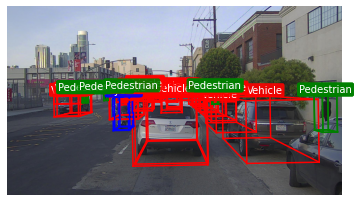

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pandaset import geometry

# choose frame + camera you already loaded above
seq_idx = 0
camera_name = "front_camera"
cam = seq002.camera[camera_name]
cam.load()

# --- helper: 8 corners in LiDAR coords
def get_corners(row):
    x,y,z = row["position.x"], row["position.y"], row["position.z"]
    dx,dy,dz = row["dimensions.x"], row["dimensions.y"], row["dimensions.z"]
    yaw = row["yaw"]
    # base cube
    c = np.array([[ dx/2,  dy/2, -dz/2],
                  [-dx/2,  dy/2, -dz/2],
                  [-dx/2, -dy/2, -dz/2],
                  [ dx/2, -dy/2, -dz/2],
                  [ dx/2,  dy/2,  dz/2],
                  [-dx/2,  dy/2,  dz/2],
                  [-dx/2, -dy/2,  dz/2],
                  [ dx/2, -dy/2,  dz/2]])
    R = np.array([[np.cos(yaw), -np.sin(yaw), 0],
                  [np.sin(yaw),  np.cos(yaw), 0],
                  [0,            0,           1]])
    return c @ R.T + np.array([x,y,z])

# --- remap labels to 3 KITTI-like classes
veh = {"Car","Truck","Bus","Medium-sized Truck","Pickup Truck","Construction Vehicle",
       "Motorized Scooter","Scooter","Bicycle","Motorcycle","SUV","Van"}
ped = {"Pedestrian","Pedestrian with Object","Pedestrian Group"}
cyc = {"Cyclist","Tricyclist"}

def kitti_class(lbl):
    if lbl in ped: return "Pedestrian"
    if (lbl in cyc) or (lbl in {"Bicycle","Motorcycle","Scooter","Motorized Scooter"}): return "Cyclist"
    if lbl in veh: return "Vehicle"
    return None  # ignore others

# image
img = np.array(cam[seq_idx])
plt.imshow(img)
plt.axis('off')

# draw cuboids
edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
colors = {"Vehicle":"r","Pedestrian":"g","Cyclist":"b"}

frame_cuboids = seq002.cuboids[seq_idx]
for _, row in frame_cuboids.iterrows():
    cls = kitti_class(row["label"])
    if cls is None: 
        continue
    corners3d = get_corners(row)
    proj2d, _, _ = geometry.projection(
        lidar_points=corners3d,
        camera_data=cam[seq_idx],
        camera_pose=cam.poses[seq_idx],
        camera_intrinsics=cam.intrinsics,
        filter_outliers=True
    )
    if proj2d.shape[0] != 8: 
        continue
    col = colors[cls]
    for i,j in edges:
        plt.plot([proj2d[i,0], proj2d[j,0]],[proj2d[i,1], proj2d[j,1]], col, linewidth=1.5)
    # label
    cx, cy = proj2d[:,0].mean(), proj2d[:,1].min()-6
    plt.text(cx, cy, cls, color='w', ha='center', va='bottom',
             bbox=dict(facecolor=col, alpha=0.9, pad=2, edgecolor='none', boxstyle="round,pad=0.2"))

plt.show()
